# Studi Kasus Mandiri 3 — Eksplorasi Data Sensor Kualitas Produk pada Lini Perakitan Elektronik
Sebuah pabrik perakitan komponen elektronik memasang sensor otomatis pada stasiun uji akhir (*final test station*) untuk merekam parameter kelistrikan setiap unit produk sebelum dikirim ke pelanggan. Tim rekayasa kualitas ingin memahami karakteristik data hasil pengujian ini sebagai langkah awal sebelum membangun model klasifikasi otomatis di pertemuan mendatang.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Memastikan visualisasi muncul langsung di bawah sel
%matplotlib inline
# Mengatur gaya tampilan grafik agar bersih dan rapi
sns.set_style('whitegrid')

# Memuat dataset sensor_kualitas_elektronik.csv
df = pd.read_csv('sensor_kualitas_elektronik.csv')

# Menampilkan dimensi data (jumlah baris dan kolom)
print("Dimensi data (baris, kolom):", df.shape)

# Menampilkan 10 baris pertama data
df.head(10)

Dimensi data (baris, kolom): (1800, 7)


,ID_Unit,Tegangan_Output_Volt,Arus_Output_Ampere,Suhu_Komponen_Celcius,Waktu_Uji_Detik,Line_Perakitan,Status_Akhir
0,U00001,11.874,2.160,49.2,16.6,L1,Lolos
1,U00002,11.756,2.396,43.5,17.5,L2,Lolos
2,U00003,12.292,1.790,48.5,18.1,L2,Lolos
3,U00004,11.932,1.894,35.0,20.9,L3,Lolos
4,U00005,NaN,2.202,47.9,13.8,L1,Lolos
5,U00006,12.333,2.208,49.5,14.9,L2,Lolos
6,U00007,12.409,2.274,45.9,14.3,L3,Lolos
7,U00008,NaN,2.254,52.0,20.6,L2,Lolos
8,U00009,11.476,1.617,46.7,17.7,L3,Lolos
9,U00010,11.966,1.880,45.9,15.3,L1,Lolos


Selanjutnya, kita melakukan inspeksi menyeluruh terhadap struktur dataset, tipe data, ringkasan statistik, serta mengecek jumlah missing value dan proporsi kelas pada kolom Status_Akhir.

In [3]:
# Inspeksi struktur dan tipe data
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1800 entries, 0 to 1799
Data columns (total 7 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   ID_Unit                1800 non-null   str    
 1   Tegangan_Output_Volt   1692 non-null   float64
 2   Arus_Output_Ampere     1674 non-null   float64
 3   Suhu_Komponen_Celcius  1800 non-null   float64
 4   Waktu_Uji_Detik        1800 non-null   float64
 5   Line_Perakitan         1800 non-null   str    
 6   Status_Akhir           1800 non-null   str    
dtypes: float64(4), str(3)
memory usage: 121.4 KB


In [4]:
# Ringkasan statistik data numerik
df.describe()

,Tegangan_Output_Volt,Arus_Output_Ampere,Suhu_Komponen_Celcius,Waktu_Uji_Detik
count,1692.000000,1674.000000,1800.000000,1800.000000
mean,11.864223,2.055350,45.927667,17.878222
std,0.488638,0.274643,6.688752,3.004420
min,9.750000,1.191000,22.100000,8.600000
25%,11.636000,1.873000,41.300000,15.800000
50%,11.923000,2.036000,45.500000,17.900000
75%,12.193000,2.228000,50.000000,19.900000
max,13.753000,3.049000,76.000000,28.900000


In [12]:
# Ringkasan statistik data kategorik (object)
df.describe(include=['str'])

,ID_Unit,Line_Perakitan,Status_Akhir
count,1800,1800,1800
unique,1800,3,2
top,U00001,L1,Lolos
freq,1,610,1565


In [6]:
# Menghitung jumlah missing value pada setiap kolom
df.isnull().sum()

ID_Unit                    0
Tegangan_Output_Volt     108
Arus_Output_Ampere       126
Suhu_Komponen_Celcius      0
Waktu_Uji_Detik            0
Line_Perakitan             0
Status_Akhir               0
dtype: int64

In [7]:
# Menganalisis proporsi unit dengan status Lolos vs Gagal
proporsi_status = df['Status_Akhir'].value_counts()
persentase_status = df['Status_Akhir'].value_counts(normalize=True) * 100

print("Jumlah Unit Berdasarkan Status Akhir:")
print(proporsi_status)
print("\nPersentase Unit Berdasarkan Status Akhir (%):")
print(persentase_status)

Jumlah Unit Berdasarkan Status Akhir:
Status_Akhir
Lolos    1565
Gagal     235
Name: count, dtype: int64

Persentase Unit Berdasarkan Status Akhir (%):
Status_Akhir
Lolos    86.944444
Gagal    13.055556
Name: proportion, dtype: float64


In [8]:
df_clean = df.copy() # Membuat salinan data agar data asli aman

# 1. Menghitung dan mengisi missing value pada kolom Tegangan dengan nilai Median
median_tegangan = df_clean['Tegangan_Output_Volt'].median()
df_clean['Tegangan_Output_Volt'] = df_clean['Tegangan_Output_Volt'].fillna(median_tegangan)

# 2. Menghitung dan mengisi missing value pada kolom Arus dengan nilai Median
median_arus = df_clean['Arus_Output_Ampere'].median()
df_clean['Arus_Output_Ampere'] = df_clean['Arus_Output_Ampere'].fillna(median_arus)

# 3. Verifikasi apakah data sudah bersih
print("Jumlah missing value setelah pembersihan:")
print(df_clean.isnull().sum())

Jumlah missing value setelah pembersihan:
ID_Unit                  0
Tegangan_Output_Volt     0
Arus_Output_Ampere       0
Suhu_Komponen_Celcius    0
Waktu_Uji_Detik          0
Line_Perakitan           0
Status_Akhir             0
dtype: int64


**Alasan Penanganan Missing Value:**
Metode imputasi menggunakan nilai median dipilih untuk mengisi data kosong pada kolom *Tegangan_Output_Volt* dan *Arus_Output_Ampere* agar ukuran dataset asli tetap utuh. Langkah ini diambil karena kegagalan pembacaan sensor tersebut terjadi secara acak dan tidak berkaitan dengan status kelayakan fisik produk. Selain itu, nilai median dipilih karena terbukti lebih kebal (*robust*) terhadap pengaruh fluktuasi atau nilai ekstrem (*outlier*) dibandingkan rata-rata.

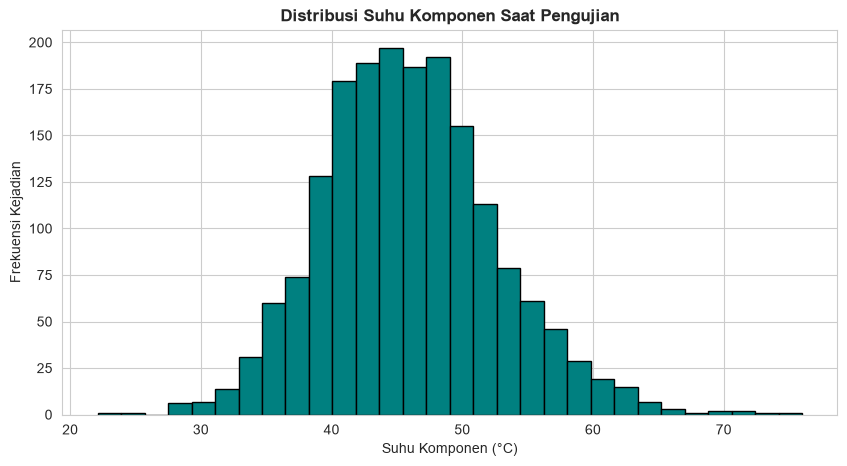

In [9]:
plt.figure(figsize=(10, 5))
df_clean['Suhu_Komponen_Celcius'].hist(bins=30, color='teal', edgecolor='black')

plt.title('Distribusi Suhu Komponen Saat Pengujian', fontsize=12, fontweight='bold')
plt.xlabel('Suhu Komponen (°C)', fontsize=10)
plt.ylabel('Frekuensi Kejadian', fontsize=10)
plt.show()

**Insight Visualisasi 1:**
Distribusi suhu komponen saat pengujian membentuk pola yang mendekati distribusi normal, dengan sebagian besar nilai berada pada kisaran 40–50°C. Hanya sedikit unit yang memiliki suhu sangat rendah maupun sangat tinggi, sehingga kondisi pengujian secara umum berada pada rentang suhu yang stabil.

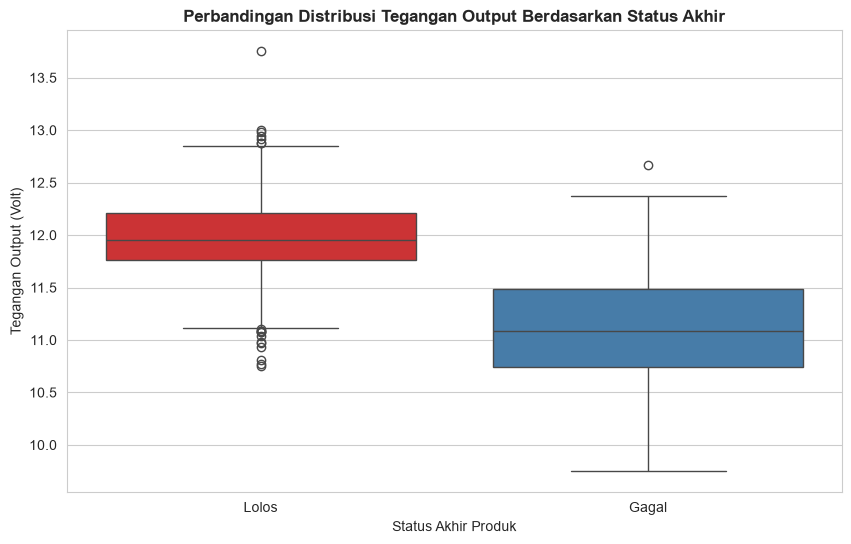

In [10]:
plt.figure(figsize=(10, 6))
sns.boxplot(
    data=df_clean,
    x='Status_Akhir',
    y='Tegangan_Output_Volt',
    hue='Status_Akhir',
    palette='Set1',
    legend=False
)

plt.title('Perbandingan Distribusi Tegangan Output Berdasarkan Status Akhir', fontsize=12, fontweight='bold')
plt.xlabel('Status Akhir Produk', fontsize=10)
plt.ylabel('Tegangan Output (Volt)', fontsize=10)
plt.show()

**Insight Visualisasi 2:**
Visualisasi ini memberikan indikasi awal bahwa tegangan output (*Output Voltage*) berhubungan erat dengan status kelulusan produk. Produk yang memiliki tegangan output mendekati nilai standar cenderung lolos pengujian, sedangkan tegangan yang lebih rendah memiliki kecenderungan lebih besar untuk menghasilkan status gagal.

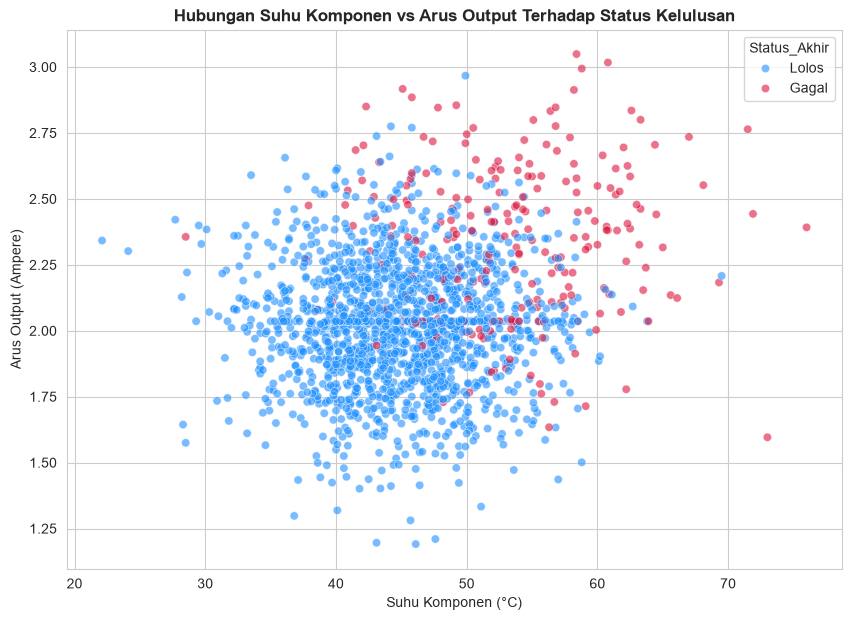

In [11]:
plt.figure(figsize=(10, 7))
sns.scatterplot(
    data=df_clean,
    x='Suhu_Komponen_Celcius',
    y='Arus_Output_Ampere',
    hue='Status_Akhir',
    palette={'Lolos': 'dodgerblue', 'Gagal': 'crimson'},
    alpha=0.6
)

plt.title('Hubungan Suhu Komponen vs Arus Output Terhadap Status Kelulusan', fontsize=12, fontweight='bold')
plt.xlabel('Suhu Komponen (°C)', fontsize=10)
plt.ylabel('Arus Output (Ampere)', fontsize=10)
plt.show()

**Insight Visualisasi 3:**
Visualisasi ini menunjukkan bahwa suhu komponen dan arus output memiliki keterkaitan dengan status kelulusan unit. Semakin tinggi suhu komponen, peluang produk mengalami kegagalan (*Gagal*) cenderung meningkat. Oleh karena itu, parameter-parameter sensor kelistrikan dan suhu ini sangat potensial untuk dijadikan fitur utama dalam pembangunan model klasifikasi prediktif pada pertemuan mendatang.